In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harshrishi7/geosights/featured_master_dataset.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/kaggle/input/datasets/harshrishi7/geosights/featured_master_dataset.csv')

TOP CONGESTED STATIONS

In [5]:
station_congestion = (
    df.groupby('station_id')['congestion_score']
    .mean()
    .sort_values(ascending=False)
)


In [6]:
top_congested = station_congestion.head(10)

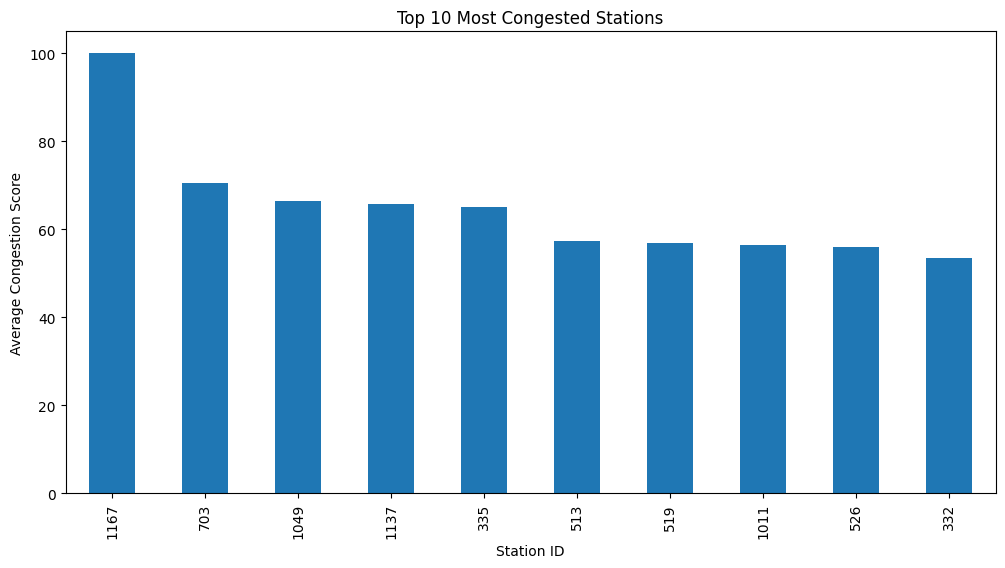

In [7]:
plt.figure(figsize=(12,6))

top_congested.plot(kind='bar')

plt.title('Top 10 Most Congested Stations')
plt.xlabel('Station ID')
plt.ylabel('Average Congestion Score')

plt.show()

A small subset of stations experiences disproportionately high congestion,
indicating uneven charging demand distribution across the network.

**TOP REVENUE STATIONS**

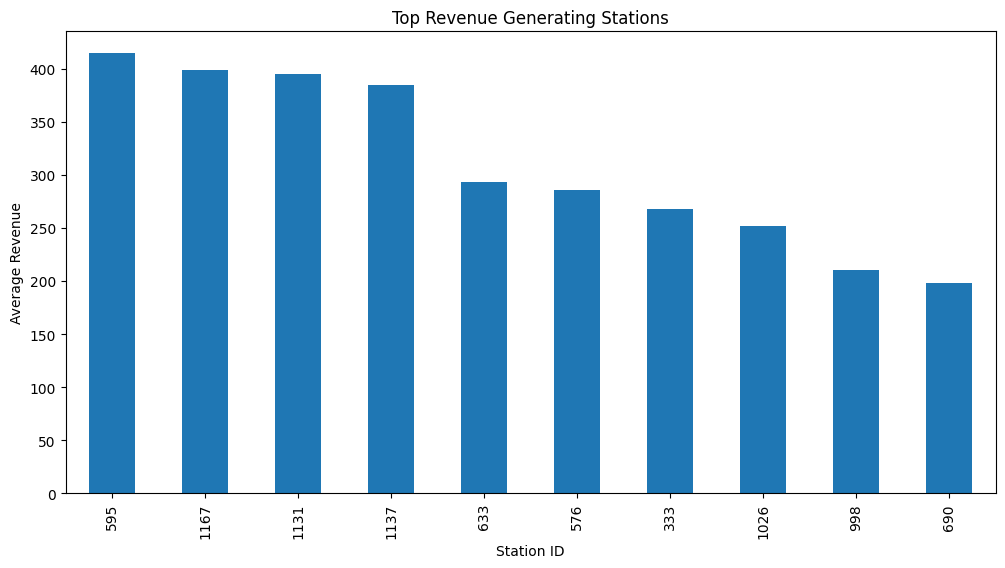

In [8]:
station_revenue = (
    df.groupby('station_id')['revenue']
    .mean()
    .sort_values(ascending=False)
)
top_revenue = station_revenue.head(10)
plt.figure(figsize=(12,6))

top_revenue.plot(kind='bar')

plt.title('Top Revenue Generating Stations')
plt.xlabel('Station ID')
plt.ylabel('Average Revenue')

plt.show()

Revenue generation is highly concentrated among a limited number of stations,
suggesting strong demand clustering within specific regions.

**UTILIZATION ANALYSIS**

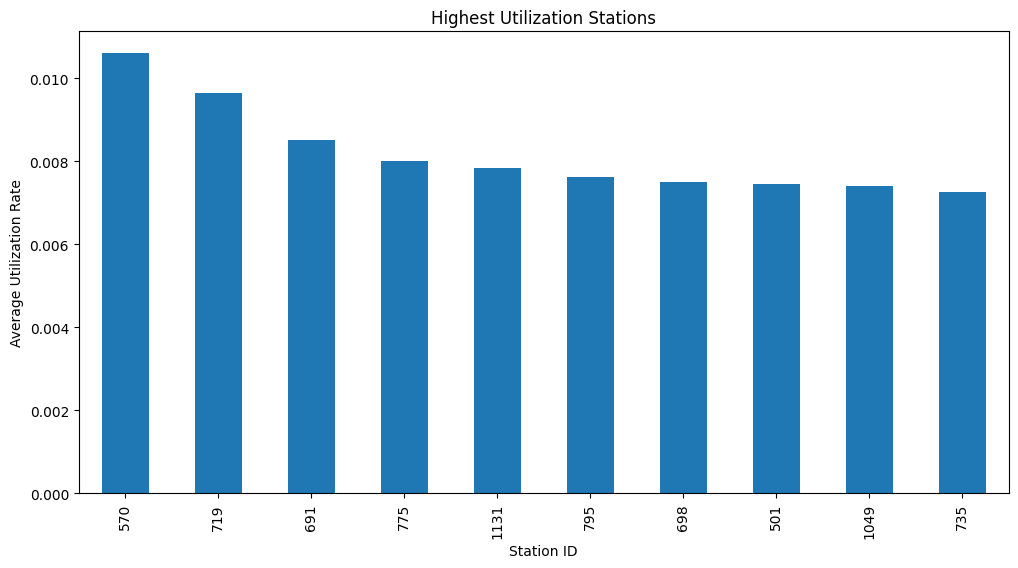

In [9]:
station_util = (
    df.groupby('station_id')['charger_utilization_rate']
    .mean()
    .sort_values(ascending=False)
)
top_util = station_util.head(10)
plt.figure(figsize=(12,6))

top_util.plot(kind='bar')

plt.title('Highest Utilization Stations')
plt.xlabel('Station ID')
plt.ylabel('Average Utilization Rate')

plt.show()

Several stations exhibit persistently high utilization rates,
indicating elevated infrastructure stress and possible capacity limitations.

**UNDERUTILIZED STATIONS**

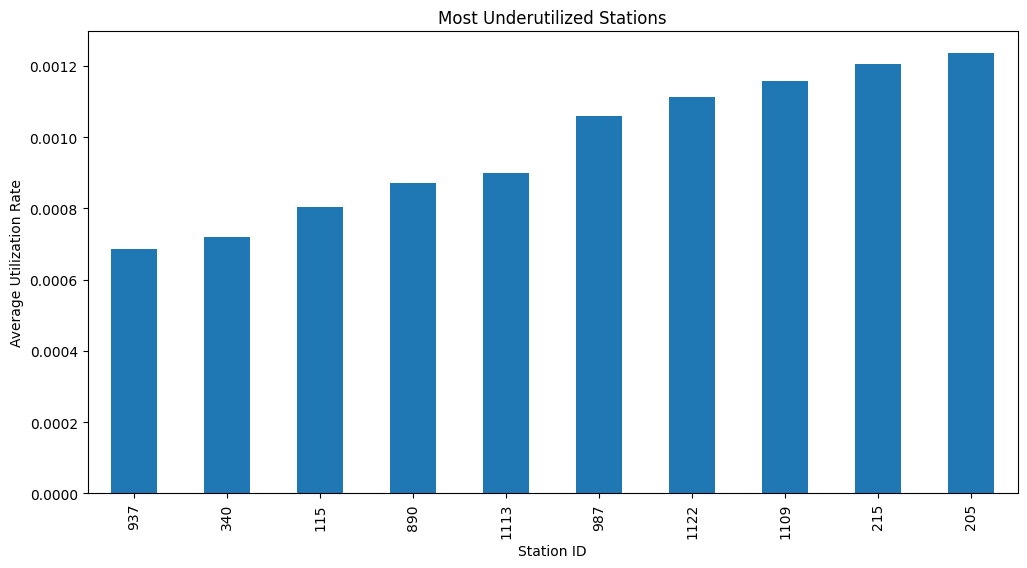

In [10]:
underutilized = (
    df.groupby('station_id')['charger_utilization_rate']
    .mean()
    .sort_values()
    .head(10)
)
plt.figure(figsize=(12,6))

underutilized.plot(kind='bar')

plt.title('Most Underutilized Stations')
plt.xlabel('Station ID')
plt.ylabel('Average Utilization Rate')

plt.show()

Several charging stations remain persistently underutilized,
suggesting inefficient infrastructure allocation or weak local demand.

**CBD VS NON-CBD ANALYSIS**

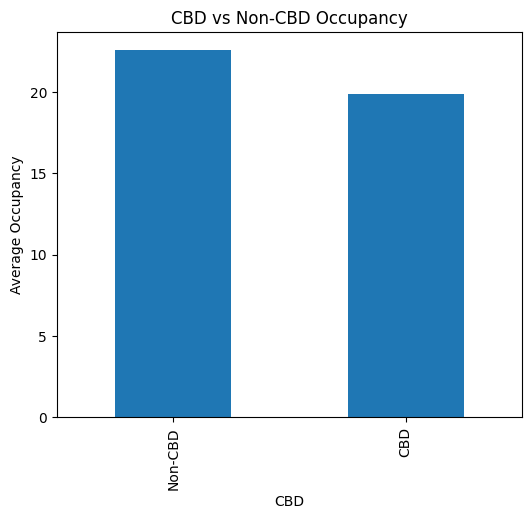

In [11]:
cbd_analysis = (
    df.groupby('CBD')['occupancy']
    .mean()
)
plt.figure(figsize=(6,5))

cbd_analysis.plot(kind='bar')

plt.xticks([0,1],['Non-CBD','CBD'])

plt.title('CBD vs Non-CBD Occupancy')
plt.ylabel('Average Occupancy')

plt.show()

Charging demand may be more concentrated in residential or suburban regions
rather than dense commercial business districts.

**FAST VS SLOW CHARGER ANALYSIS**

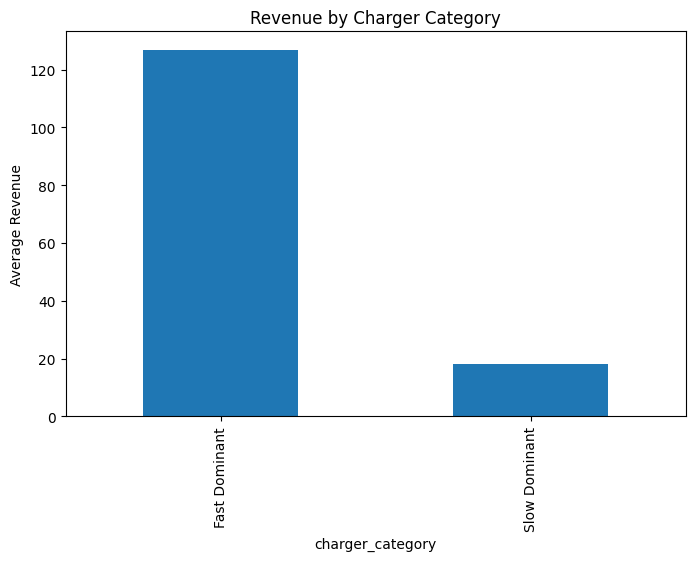

In [12]:
charger_analysis = (
    df.groupby('charger_category')['revenue']
    .mean()
)
plt.figure(figsize=(8,5))

charger_analysis.plot(kind='bar')

plt.title('Revenue by Charger Category')
plt.ylabel('Average Revenue')

plt.show()

Fast-dominant charging stations generate significantly higher revenue,
suggesting stronger demand intensity among rapid-charging users.

**OCCUPANCY DENSITY HOTSPOTS**

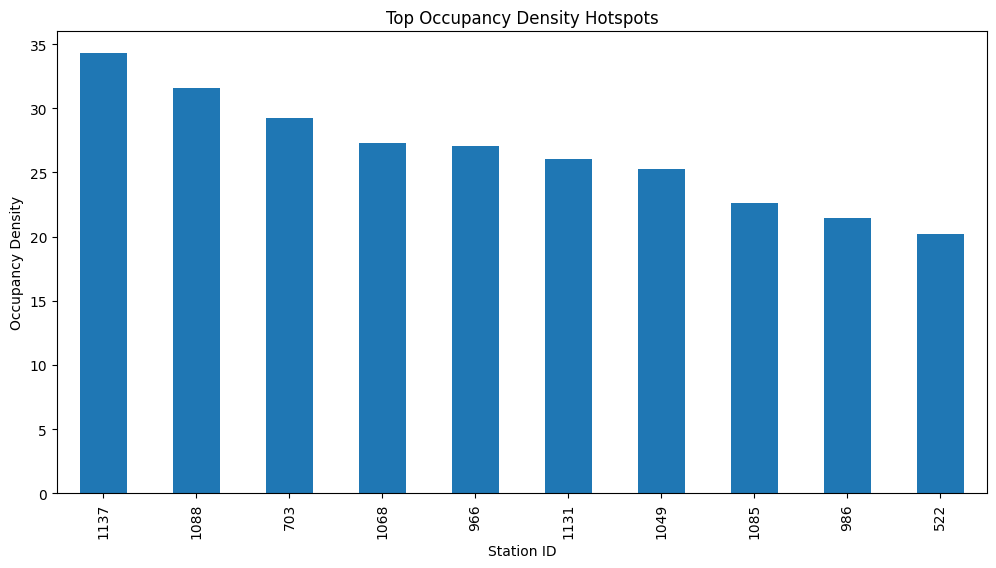

In [13]:
density_hotspots = (
    df.groupby('station_id')['occupancy_density']
    .mean()
    .sort_values(ascending=False)
)
top_density = density_hotspots.head(10)
plt.figure(figsize=(12,6))

top_density.plot(kind='bar')

plt.title('Top Occupancy Density Hotspots')
plt.xlabel('Station ID')
plt.ylabel('Occupancy Density')

plt.show()

Certain stations exhibit extremely high occupancy density,
highlighting severe localized charging pressure.

**QUEUE HOTSPOT ANALYSIS**

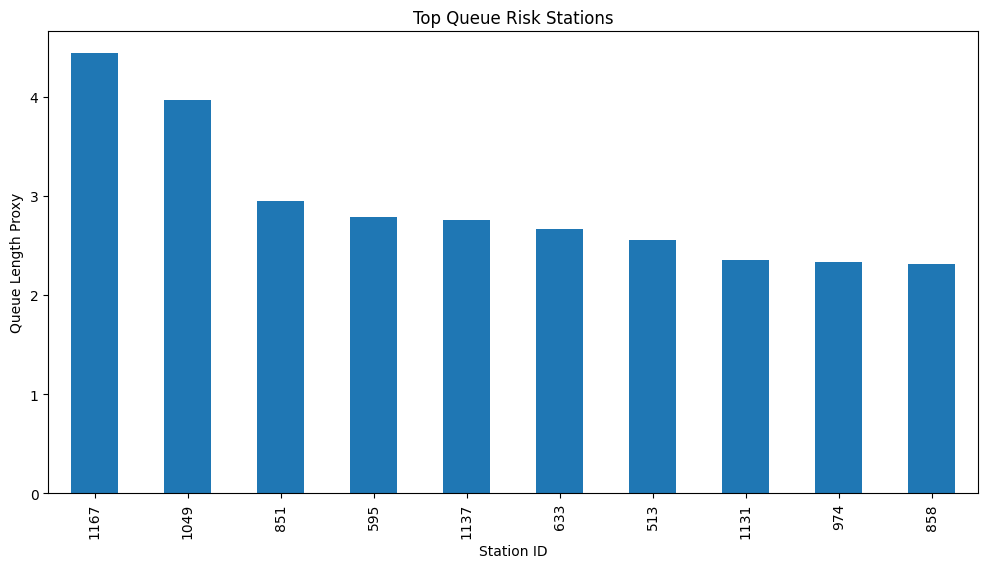

In [14]:
queue_hotspots = (
    df.groupby('station_id')['queue_length_proxy']
    .mean()
    .sort_values(ascending=False)
)
top_queue = queue_hotspots.head(10)
plt.figure(figsize=(12,6))

top_queue.plot(kind='bar')

plt.title('Top Queue Risk Stations')
plt.xlabel('Station ID')
plt.ylabel('Queue Length Proxy')

plt.show()

Queue risk is heavily concentrated among a small subset of stations,
suggesting elevated waiting-time pressure in localized regions.

**CREATE STATION RANKING TABLE**

In [15]:
station_summary = (
    df.groupby('station_id')
    .agg({
        'occupancy':'mean',
        'revenue':'mean',
        'congestion_score':'mean',
        'queue_length_proxy':'mean',
        'charger_utilization_rate':'mean'
    })
)
station_summary.sort_values(
    by='congestion_score',
    ascending=False
).head(10)

,occupancy,revenue,congestion_score,queue_length_proxy,charger_utilization_rate
station_id,,,,,
1167,138.049653,398.700010,99.988676,4.435288,0.005853
703,98.767014,30.542238,70.502943,1.516017,0.002910
1049,91.651505,43.321954,66.401441,3.966212,0.007411
1137,91.193171,384.688478,65.698965,2.760345,0.005752
335,90.076736,49.542404,65.003739,2.198202,0.004797
513,79.133681,36.901908,57.334080,2.557333,0.005801
519,80.029630,74.825010,56.857782,1.159863,0.002804
1011,78.168866,32.914804,56.426420,1.370485,0.003310
526,77.911806,38.670153,56.009757,1.483899,0.003554
